<a href="https://colab.research.google.com/github/chaithu466/breast--cancer-prediction/blob/main/Student_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

In [12]:
df = pd.read_csv("Student performance prediction.csv")
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [13]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
academic_level,0
study_hours,0
self_study_hours,0
online_classes_hours,0
social_media_hours,0
gaming_hours,0
sleep_hours,0


In [15]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])


In [18]:
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

In [22]:
df['result'] = df['exam_score'].apply(lambda x: 1 if x>=40 else 0)
X = df.drop(['exam_score','result'], axis=1)
y = df['result']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
print(y_train.value_counts())

result
0    3796
1     204
Name: count, dtype: int64


In [29]:
print(X_train.dtypes)

student_id                int64
age                       int64
gender                    int64
academic_level           object
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality         object
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
dtype: object


In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['academic_level'] = le.fit_transform(df['academic_level'])
df['internet_quality'] = le.fit_transform(df['internet_quality'])

In [31]:
print(df.dtypes)

student_id                int64
age                       int64
gender                    int64
academic_level            int64
study_hours             float64
self_study_hours        float64
online_classes_hours    float64
social_media_hours      float64
gaming_hours            float64
sleep_hours             float64
screen_time_hours       float64
exercise_minutes          int64
caffeine_intake_mg        int64
part_time_job             int64
upcoming_deadline         int64
internet_quality          int64
mental_health_score       int64
focus_index             float64
burnout_level           float64
productivity_score      float64
exam_score              float64
result                    int64
dtype: object


In [32]:
X = df.drop("result", axis=1)
y = df["result"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model1 = LogisticRegression(max_iter=1000, class_weight='balanced')
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred1))

Accuracy: 0.976


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
model2 = LinearRegression()
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred2))

MSE: 0.029806503439979246


In [39]:
class_weight='balanced'

In [43]:
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1,1)
y = np.array([0, 0, 0, 0, 1, 0, 1, 1, 1, 1])

In [44]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

In [45]:
X_range = np.linspace(0, 10, 100).reshape(-1,1)
y_prob = model.predict_proba(X_range)[:,1]

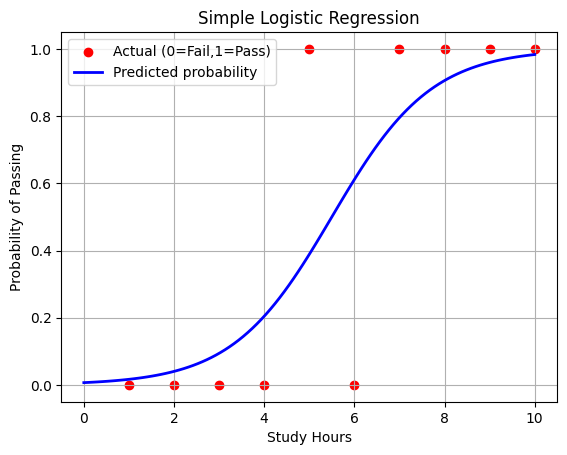

In [46]:
plt.scatter(X, y, color='red', label='Actual (0=Fail,1=Pass)')
plt.plot(X_range, y_prob, color='blue', linewidth=2, label='Predicted probability')
plt.xlabel("Study Hours")
plt.ylabel("Probability of Passing")
plt.title("Simple Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()



In [47]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, y)


DecisionTreeClassifier(max_depth=3, random_state=42)

In [48]:
X_range = np.linspace(0, 10, 100).reshape(-1,1)
y_pred = model.predict(X_range)

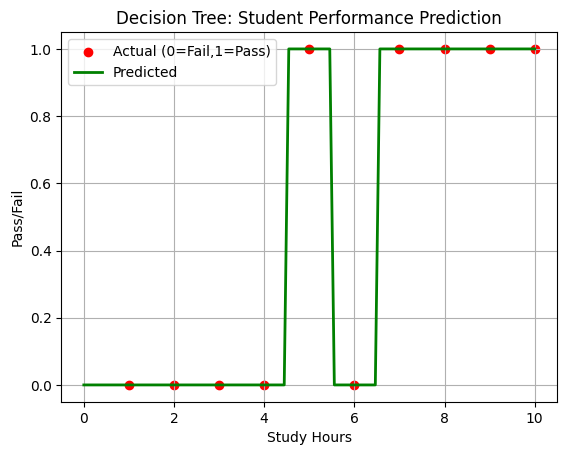

In [49]:
plt.scatter(X, y, color='red', label='Actual (0=Fail,1=Pass)')
plt.plot(X_range, y_pred, color='green', linewidth=2, label='Predicted')
plt.xlabel("Study Hours")
plt.ylabel("Pass/Fail")
plt.title("Decision Tree: Student Performance Prediction")
plt.legend()
plt.grid(True)
plt.show()

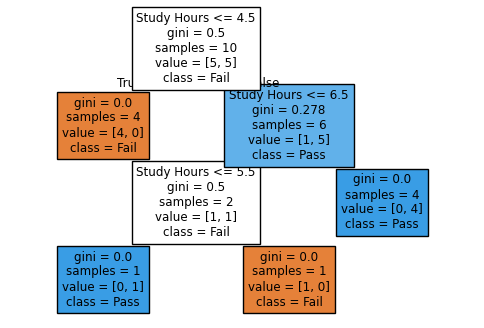

In [51]:
from sklearn.tree import plot_tree
plt.figure(figsize=(6,4))
plot_tree(model, feature_names=["Study Hours"], class_names=["Fail","Pass"], filled=True)
plt.show()

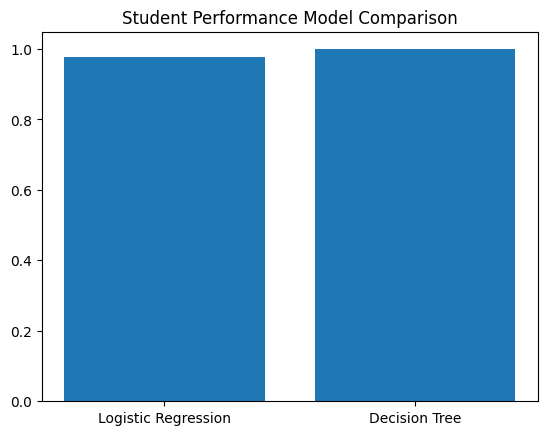

In [37]:
# Calculate acc1 for Logistic Regression
acc1 = accuracy_score(y_test, pred1)

# Train and evaluate Decision Tree Classifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_test)
acc2 = accuracy_score(y_test, pred_dt)

models = ['Logistic Regression', 'Decision Tree']
accuracies = [acc1, acc2]

plt.figure()
plt.bar(models, accuracies)
plt.title("Student Performance Model Comparison")
plt.show()